 # Musical Analysis

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
music_2010 = pd.read_csv('2010.csv')
music_2011 = pd.read_csv('2011.csv')
music_2012 = pd.read_csv('2012.csv')
music_2013 = pd.read_csv('2013.csv')
music_2014 = pd.read_csv('2014.csv')
music_2015 = pd.read_csv('2015.csv')
music_2016 = pd.read_csv('2016.csv')
music_2017 = pd.read_csv('2017.csv')
music_2018 = pd.read_csv('2018.csv')
music_2019 = pd.read_csv('2019.csv')

In [5]:
music_2010 = music_2010.rename(columns={'Unnamed: 0': 'ID'}).set_index('ID')
music_2011 = music_2011.rename(columns={'Unnamed: 0': 'ID'}).set_index('ID')
music_2012 = music_2012.rename(columns={'Unnamed: 0': 'ID'}).set_index('ID')
music_2013 = music_2013.rename(columns={'Unnamed: 0': 'ID'}).set_index('ID')
music_2014 = music_2014.rename(columns={'Unnamed: 0': 'ID'}).set_index('ID')
music_2015 = music_2015.rename(columns={'Unnamed: 0': 'ID'}).set_index('ID')
music_2016 = music_2016.rename(columns={'Unnamed: 0': 'ID'}).set_index('ID')
music_2017 = music_2017.rename(columns={'Unnamed: 0': 'ID'}).set_index('ID')
music_2018 = music_2018.rename(columns={'Unnamed: 0': 'ID'}).set_index('ID')
music_2019 = music_2019.rename(columns={'Unnamed: 0': 'ID'}).set_index('ID')

In [6]:
# music_2010.head()

In [7]:
all_top_songs = pd.concat([music_2010, music_2011,music_2012, music_2013, music_2014, music_2015, music_2016,
                          music_2017, music_2018, music_2019]).reset_index()

In [8]:
all_top_songs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 603 entries, 0 to 602
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         603 non-null    int64 
 1   title      603 non-null    object
 2   artist     603 non-null    object
 3   top genre  603 non-null    object
 4   year       603 non-null    int64 
 5   bpm        603 non-null    int64 
 6   nrgy       603 non-null    int64 
 7   dnce       603 non-null    int64 
 8   dB         603 non-null    int64 
 9   live       603 non-null    int64 
 10  val        603 non-null    int64 
 11  dur        603 non-null    int64 
 12  acous      603 non-null    int64 
 13  spch       603 non-null    int64 
 14  pop        603 non-null    int64 
dtypes: int64(12), object(3)
memory usage: 70.8+ KB


In [24]:
# all_top_songs.describe()
all_top_songs.tail()

,ID,title,artist,top genre,year,bpm,nrgy,dnce,dB,live,val,dur,acous,spch,pop
598,599,Find U Again (feat. Camila Cabello),Mark Ronson,dance pop,2019,104,66,61,-7,20,16,176,1,3,75
599,600,Cross Me (feat. Chance the Rapper & PnB Rock),Ed Sheeran,pop,2019,95,79,75,-6,7,61,206,21,12,75
600,601,"No Brainer (feat. Justin Bieber, Chance the Ra...",DJ Khaled,dance pop,2019,136,76,53,-5,9,65,260,7,34,70
601,602,Nothing Breaks Like a Heart (feat. Miley Cyrus),Mark Ronson,dance pop,2019,114,79,60,-6,42,24,217,1,7,69
602,603,Kills You Slowly,The Chainsmokers,electropop,2019,150,44,70,-9,13,23,213,6,6,67


# What is the most popular song in the dataset?
The most popular song in the dataset is Memories by Maroon 5 with 99 popularity ratings.
I first filtered the dataset for songs with a popularity score over 50, sorted them from highest to lowest, and then sliced the top result to isolate the single most popular track.


In [10]:
popular_song = all_top_songs[all_top_songs['pop']> 50]
popular_song = popular_song.sort_values(by=['pop'], ascending=False)[:1]
popular_song

,ID,title,artist,top genre,year,bpm,nrgy,dnce,dB,live,val,dur,acous,spch,pop
572,573,Memories,Maroon 5,pop,2019,91,32,76,-7,8,57,189,84,5,99


# What artist has the most songs in the dataset?
The artist with most number of songs in the dataset is Katy Perry with 17 songs.
I grouped the data by artist to count their total songs, renamed the column for clarity, and then sorted the list to display the top  artist with the most tracks.

In [11]:
all_top_songs['artist'].nunique() # number of artists

184

In [25]:
artists_songs = all_top_songs.groupby('artist').agg({'title': 'count'})
artists_songs.columns = ['num of songs']
artists_songs = artists_songs.reset_index()
artists_songs.sort_values(by=['num of songs'], ascending=False)[:1]


,artist,num of songs
86,Katy Perry,17


# What is the most popular genre of music in the dataset?
The most popular genre is **dance pop** which appears 327 times in the data set.
I used value_counts() to calculate the frequency of every genre in the dataset and then applied .head() to extract the top 5 most common genres.


In [13]:
all_top_songs['top genre'].value_counts().head()

top genre
dance pop        327
pop               60
canadian pop      34
barbadian pop     15
boy band          15
Name: count, dtype: int64

# Are there any songs in the dataset more than once?
Yes, there are 19 songs title which appears more than once in the dataset
I used ".duplicated()" on the song titles to identify repeats and then applied ".sum()" to calculate the total count of duplicate tracks in the dataset."

In [14]:
duplicate_songs = all_top_songs.duplicated(subset=['title']).sum()
duplicate_songs

19

# Is there a relationship between popularity and danceability?
It is positive, meaning, as danceability increases, popularity tends to increase "slightly".
but since the value of the correlation as calculated below which is (0.12) is so low and close to 0, the relationship is negligible.
I created a regression plot using Seaborn to visualize the relationship between danceability and popularity, adding a trend line in red and adjusting the transparency of the data points to make overlapping values clearer.
after, I applied correlation formula on popularity and danceability.


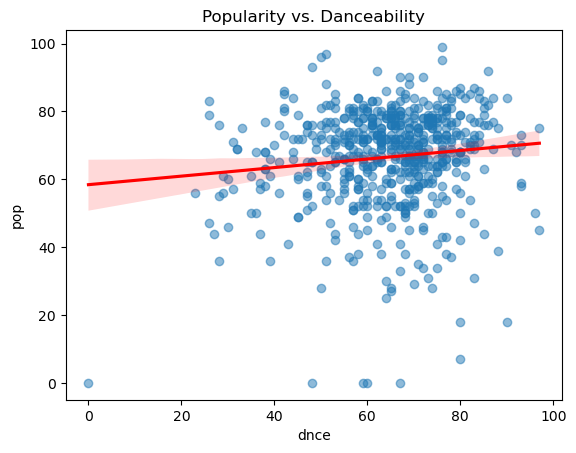

In [15]:
sns.regplot(data=all_top_songs, x='dnce', y='pop', 
            line_kws={'color': 'red'}, scatter_kws={'alpha': 0.5})

plt.title('Popularity vs. Danceability')
plt.show()

In [16]:
correlation = all_top_songs['pop'].corr(all_top_songs['dnce'])
print(f"Correlation between popularity and danceability: {correlation:.2f}")

Correlation between popularity and danceability: 0.12


# Does having a higher bpm led to having a higher energy score?
The correlation between BPM and energy is 0.126, indicating a weak positive relationship. While higher bpm songs tends
to have slightly higher energy scores, bpm alone does not strongly determine a song's energy.
I achieved this by creating a seaborn scatterplot to visualize the relationship between bpm and energy score and then used
correlation formula on bpm and energy score to find their correlation.

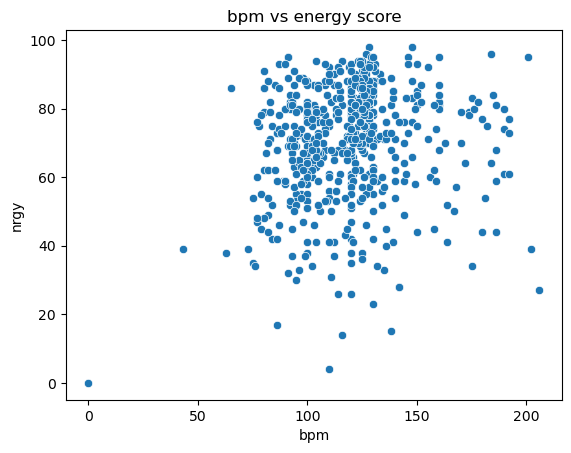

In [17]:
sns.scatterplot(data=all_top_songs, y= 'nrgy', x='bpm')
plt.title('bpm vs energy score')
plt.show()

In [18]:
correlation = all_top_songs['bpm'].corr(all_top_songs['nrgy'])
correlation

0.1261700649431028

# Which genre has the highest energy score?
The genre with the highest energy score is french indie pop with an average energy score of **89.0**.
I grouped the data by genre to calculate the average energy for each, then sorted the results to isolate the single highest energy genre.


In [19]:
highest = all_top_songs.groupby('top genre').agg({'nrgy': 'mean'})
highest.sort_values(by='nrgy', ascending=False).reset_index()[:1]

,top genre,nrgy
0,french indie pop,89.0


# What percentage of songs may have been recorded live? 
Considering any song above 50 in the live column to be recorded live, the percentage
of live recorded songs is **3%**.
I achieved this by counting all the  songs which is above 50 in the live column and dividing it by the total number of songs in the dataset. And then multiplying the answer by 100.


In [20]:
live_songs = all_top_songs[all_top_songs['live'] > 50]
percentage = (len(live_songs)/ len(all_top_songs)) * 100
round(percentage)


3

# What percentage of songs were acoustic? (Consider anything above 50 in the acoustic column to be acoustic)
The percentage of acoustic songs is **7%**. 
I achieved this by finding the number of songs which are above 50 in the 'acous' column and dividing it by the total number of songs in the dataset. And then multiplying the answer by 100

In [21]:
acoustic_songs = all_top_songs[all_top_songs['acous'] > 50]
percentage = round((len(acoustic_songs)/len(all_top_songs)) * 100)
percentage 

7

# Which year’s songs have the highest amount of spoken word in the song?
The year with the highest amount of spoken word in the song is **2017** with spoken word average of **9.8**.
I grouped the dataset by year to calculate the average speechiness for each one, then sorted the results in descending order to identify which year featured the highest  spoken word.


In [29]:
highest_spch_year = all_top_songs.groupby('year').agg({'spch': 'mean'})
highest_spch_year.sort_values(by='spch', ascending=False).reset_index()[:1]

,year,spch
0,2017,9.784615


# Exporting the combined dataset into a CSV 

In [30]:
all_top_songs.to_csv('top_spotify_songs.csv', index=False )

In [31]:
verify = pd.read_csv('top_spoftify_songs.csv')
verify.head()

FileNotFoundError: [Errno 2] No such file or directory: 'top_spoftify_songs.csv'